In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [72]:
data = pd.read_csv('Published Data/combined_COPUS_CI_data.csv')
labels = [ 'Lec', 'CG', 'CQ', 'WG', 'SQ']
COPUS_data = data[labels].values
effect_sizes = data['Effect Size'].values
n_features = COPUS_data.shape[1]
post_stds = data['PostStd'].values
pre_stds = data['PreStd'].values
std_diffs = post_stds - pre_stds
premeans = data['PreMean'].values
postmeans = data['PostMean'].values
gains = postmeans - premeans

## Effect Size and Post Test Variance Trends

Text(0, 0.5, 'Change in Std Dev')

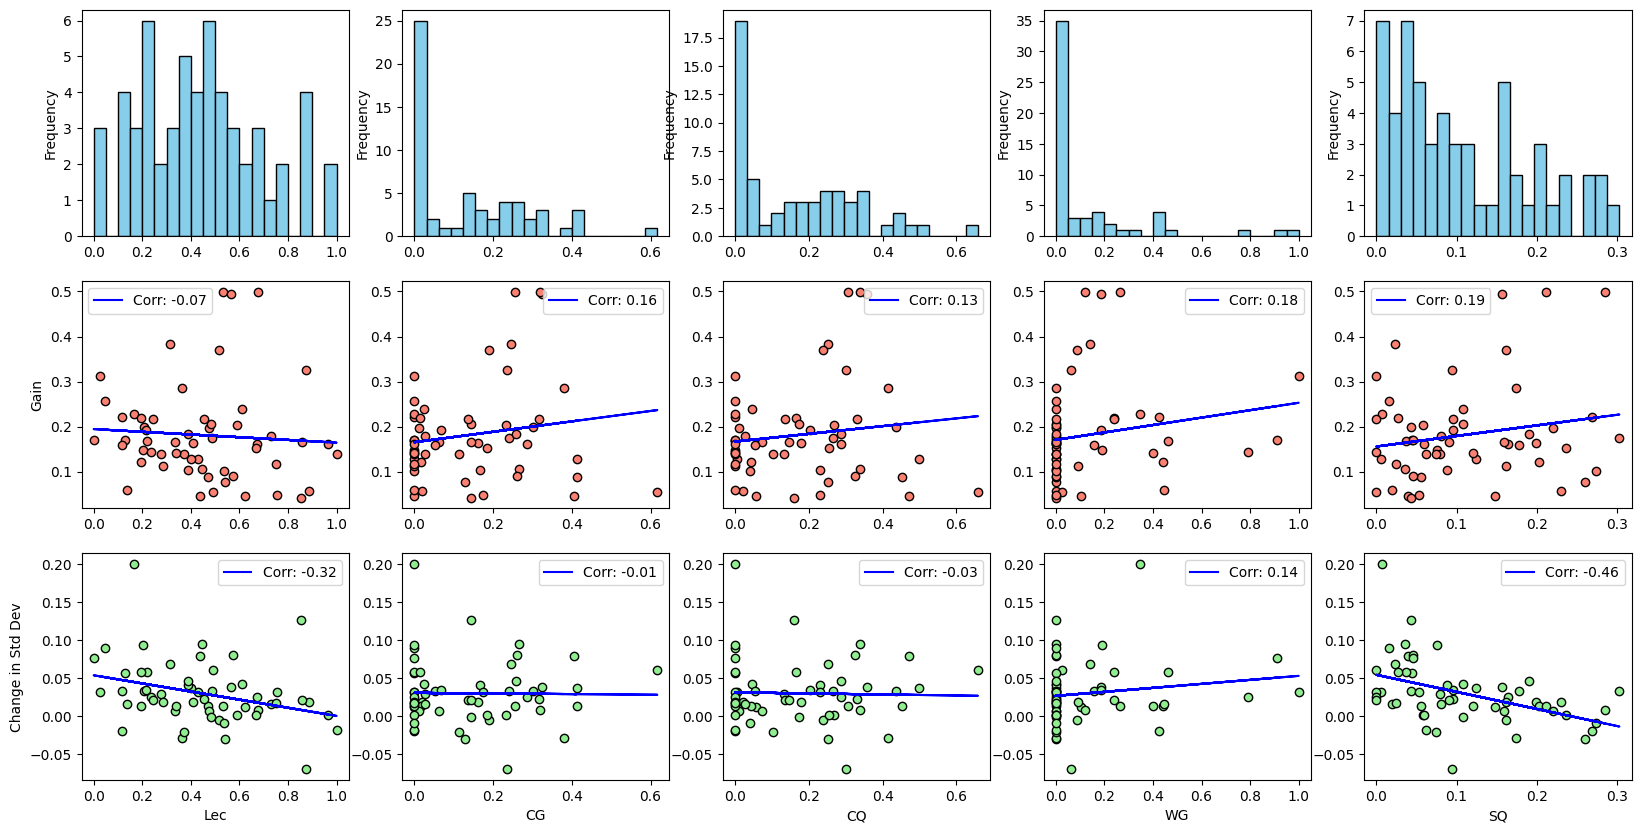

In [73]:
fig, ax = plt.subplots(3, n_features, figsize=(20, 10))
for i in range(n_features):
    ax[0, i].hist(COPUS_data[:, i], bins=20, color='skyblue', edgecolor='black')
    ax[0, i].set_ylabel('Frequency')
    
    ax[1, i].scatter(COPUS_data[:, i], gains, color='salmon', edgecolor='black')
    #fit line
    m, b = np.polyfit(COPUS_data[:, i], gains, 1)
    corr = np.corrcoef(COPUS_data[:, i], gains)[0, 1]
    ax[1, i].plot(COPUS_data[:, i], m*COPUS_data[:, i] + b, color='blue', label = f'Corr: {corr:.2f}')
    ax[1, i].legend()

    ax[2, i].scatter(COPUS_data[:, i], std_diffs, color='lightgreen', edgecolor='black')
    ax[2, i].set_xlabel(labels[i])
    #fit line
    m, b = np.polyfit(COPUS_data[:, i], std_diffs, 1)
    corr = np.corrcoef(COPUS_data[:, i], std_diffs)[0, 1]
    ax[2, i].plot(COPUS_data[:, i], m*COPUS_data[:, i] + b, color='blue', label = f'Corr: {corr:.2f}')
    ax[2, i].legend()

ax[1, 0].set_ylabel('Gain')
ax[2, 0].set_ylabel('Change in Std Dev')

## Covariance

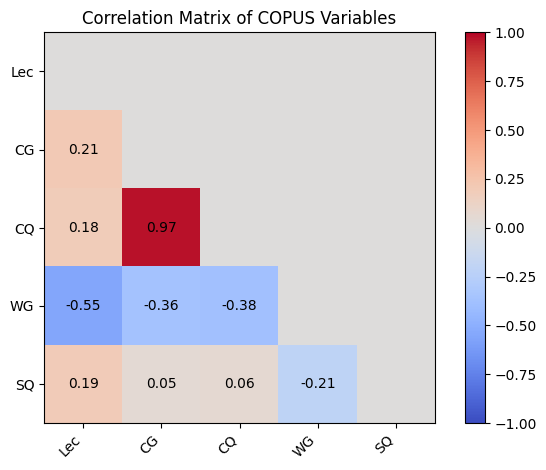

In [74]:
n_features = COPUS_data.shape[1]
corr = np.corrcoef(COPUS_data.T)


corr[corr == 1] = 0
#label each pixel with the numeric value
for i in range(n_features):
    for j in range(n_features):
        if j < i:
            plt.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', color='black')
        else: corr[i,j] = 0
plt.imshow(corr, vmin = -1, vmax=1, cmap='coolwarm')
plt.colorbar()
plt.xticks(np.arange(n_features), labels, rotation=45, ha='right')
plt.yticks(np.arange(n_features), labels)
plt.title('Correlation Matrix of COPUS Variables')
plt.tight_layout()
plt.show()


## Effect Size vs. Gain

Text(0.5, 1.0, 'Effect Size vs. Gain')

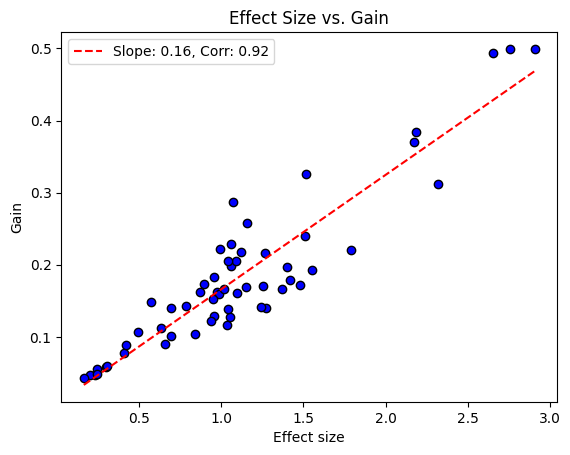

In [84]:
plt.scatter(effect_sizes, gains, color='blue', edgecolor='black'  )
plt.ylabel('Gain')
plt.xlabel('Effect size')

#fit line
m, b = np.polyfit(effect_sizes, gains, 1)
corr = np.corrcoef(effect_sizes, gains)[0, 1]
xi = np.linspace(min(effect_sizes), max(effect_sizes), 100)
plt.plot(xi, m*xi + b, 'r--', label=f'Slope: {m:.2f}, Corr: {corr:.2f}')
plt.legend()
plt.title('Effect Size vs. Gain')